<a href="https://colab.research.google.com/github/Nishal-01/Nishaltejreddy_INFO5731_Spring2026/blob/main/Chennu_Nishal_Tej_Reddy_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [10]:
# Write your code here
from google.colab import files
uploaded = files.upload()





Saving cleaned_papers (1).csv to cleaned_papers (1) (1).csv


In [11]:
import pandas as pd
import re
from collections import defaultdict

# Load dataset
df = pd.read_csv("cleaned_papers (1).csv")

# Detect correct column
print("Columns:", df.columns)

for col in df.columns:
    if 'text' in col.lower() or 'abstract' in col.lower() or 'paper' in col.lower():
        text_column = col
        break

print("Using column:", text_column)

documents = df[text_column].dropna().tolist()

# ----------------------------
# Preprocessing
# ----------------------------
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# ----------------------------
# Generate N-grams
# ----------------------------
def generate_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

# ----------------------------
# Count frequencies
# ----------------------------
unigram_counts = defaultdict(int)
bigram_counts = defaultdict(int)
trigram_counts = defaultdict(int)

for doc in documents:
    tokens = tokenize(doc)

    for word in tokens:
        unigram_counts[word] += 1

    for bg in generate_ngrams(tokens, 2):
        bigram_counts[bg] += 1

    for tg in generate_ngrams(tokens, 3):
        trigram_counts[tg] += 1

# ----------------------------
# Bigram probabilities
# ----------------------------
bigram_prob = {}

for (w1, w2), count in bigram_counts.items():
    bigram_prob[(w1, w2)] = count / unigram_counts[w1]

# Output
print("\nTop 5 Bigrams:", list(bigram_counts.items())[:5])
print("\nTop 5 Trigrams:", list(trigram_counts.items())[:5])
print("\nTop 5 Bigram Probabilities:", list(bigram_prob.items())[:5])

Columns: Index(['title', 'abstract', 'year', 'cleaned_abstract'], dtype='object')
Using column: abstract

Top 5 Bigrams: [(('in', 'the'), 713), (('the', 'current'), 59), (('current', 'age'), 2), (('age', 'of'), 4), (('of', 'the'), 933)]

Top 5 Trigrams: [(('in', 'the', 'current'), 5), (('the', 'current', 'age'), 2), (('current', 'age', 'of'), 2), (('age', 'of', 'the'), 2), (('of', 'the', 'fourth'), 3)]

Top 5 Bigram Probabilities: [(('in', 'the'), 0.19008264462809918), (('the', 'current'), 0.007137672392934914), (('current', 'age'), 0.0136986301369863), (('age', 'of'), 0.36363636363636365), (('of', 'the'), 0.14349430944324823)]


## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [12]:
# Write your code here
import math
import numpy as np
import pandas as pd
import re

# Load dataset
df = pd.read_csv("cleaned_papers (1).csv")

# 🔥 Auto-detect text column
print("Columns:", df.columns)
for col in df.columns:
    if 'text' in col.lower() or 'abstract' in col.lower() or 'paper' in col.lower():
        text_column = col
        break

print("Using column:", text_column)

documents = df[text_column].dropna().astype(str).tolist()

# ----------------------------
# Preprocessing
# ----------------------------
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

docs_tokens = [tokenize(doc) for doc in documents]

# ----------------------------
# Vocabulary
# ----------------------------
vocab = list(set(word for doc in docs_tokens for word in doc))

# ----------------------------
# TF
# ----------------------------
def compute_tf(doc_tokens):
    tf = {}
    for word in vocab:
        tf[word] = doc_tokens.count(word)
    return tf

tf_list = [compute_tf(doc) for doc in docs_tokens]

# ----------------------------
# IDF
# ----------------------------
idf = {}
N = len(docs_tokens)

for word in vocab:
    df_count = sum(1 for doc in docs_tokens if word in doc)
    idf[word] = math.log((N + 1) / (df_count + 1)) + 1

# ----------------------------
# TF-IDF
# ----------------------------
tfidf_vectors = []

for tf in tf_list:
    vec = [tf[word] * idf[word] for word in vocab]
    tfidf_vectors.append(vec)

tfidf_vectors = np.array(tfidf_vectors)

# ----------------------------
# Cosine Similarity
# ----------------------------
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Example query
query = "machine learning model"
query_tokens = tokenize(query)

query_tf = {word: query_tokens.count(word) for word in vocab}
query_vec = np.array([query_tf[word] * idf[word] for word in vocab])

# Compute similarity
scores = []
for i, vec in enumerate(tfidf_vectors):
    sim = cosine_similarity(query_vec, vec)
    scores.append((i, sim))

# Sort results
scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("\nTop 5 relevant documents:")
for idx, score in scores[:5]:
    print(f"Doc {idx} → Score: {score:.4f}")






Columns: Index(['title', 'abstract', 'year', 'cleaned_abstract'], dtype='object')
Using column: abstract

Top 5 relevant documents:
Doc 164 → Score: 0.3505
Doc 690 → Score: 0.2805
Doc 363 → Score: 0.2688
Doc 69 → Score: 0.2450
Doc 124 → Score: 0.2392


/tmp/ipykernel_233/162427772.py:72: RuntimeWarning: invalid value encountered in scalar divide
  return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


In [13]:
# Write your code here
!pip install gensim







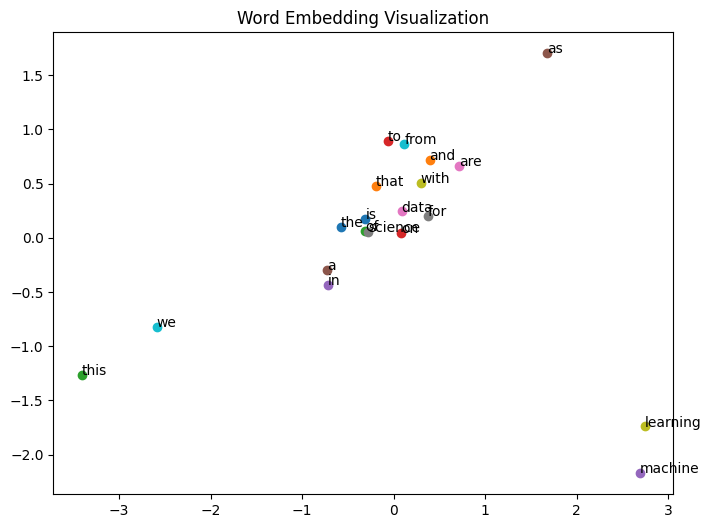


Word Similarities:
data vs model: 0.9910915
learning vs algorithm: 0.8649744
network vs training: 0.9791886


In [14]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reuse tokenize + documents from above
sentences = [tokenize(doc) for doc in documents]

# ----------------------------
# Train Word2Vec
# ----------------------------
model = Word2Vec(sentences, vector_size=300, window=5, min_count=1, workers=4)

# ----------------------------
# Select words
# ----------------------------
words = list(model.wv.index_to_key)[:20]

vectors = np.array([model.wv[word] for word in words])

# ----------------------------
# PCA Visualization
# ----------------------------
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    plt.scatter(reduced[i][0], reduced[i][1])
    plt.text(reduced[i][0], reduced[i][1], word)

plt.title("Word Embedding Visualization")
plt.show()

# ----------------------------
# Cosine similarity
# ----------------------------
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("\nWord Similarities:")

# Safe checks (prevents errors)
pairs = [("data", "model"), ("learning", "algorithm"), ("network", "training")]

for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        print(f"{w1} vs {w2}:", cosine_similarity(model.wv[w1], model.wv[w2]))
    else:
        print(f"{w1} vs {w2}: Not found in vocabulary")

## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [19]:
# The GitHub link of your final csv file


# Link: https://github.com/Nishal-01/Nishaltejreddy_INFO5731_Spring2026/blob/main/sentiment_dataset.csv



# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

I have found that this assignment was extremely helpful in learning how NLP concepts, such as N-grams, TF-IDF, and word embeddings, can be applied in practice. The hardest task in my opinion was to apply TF-IDF and N-gram models directly without inbuilt libraries because it meant that I needed to have a better insight into the underlying processes of these techniques. It also required some time to debug the issues associated with the columns in datasets as well as dealing with errors.

It was actually great fun and I really liked working on the word embedding part because it was fun to visualize the embeddings with the help of PCA and watch the similar words coming together. It provided a more intuitive insight of the way models reflect semantic relationships.

All in all, the assignment was an interesting and involving one, albeit a time-consuming one; particularly the debugging and making everything work. I believe the amount of time was fair, however, a bit more time would make it not stressful and explore concepts better.